In [1]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("../../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1}).astype(float)
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 29559 entries, (np.int64(321970859), 'cian.ru') to (np.int64(4937488939), 'avito.ru')
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Цена                     29559 non-null  float64
 1   Дата                     29559 non-null  object 
 2   Тип автора               29559 non-null  object 
 3   Город                    29559 non-null  object 
 4   Метро/Район              22098 non-null  object 
 5   Адрес                    29232 non-null  object 
 6   Описание                 29313 non-null  object 
 7   lat                      29559 non-null  float64
 8   lng                      29559 non-null  float64
 9   URL                      29559 non-null  object 
 10  Ссылки на картинки       29108 non-null  object 
 11  Расстояние до метро, км  20605 non-null  float64
 12  Этаж                     28639 non-null  float64
 13  Этажность здания

In [3]:
# !pip install nltk

In [4]:
import nltk

nltk_dir = None
nltk.download("stopwords", download_dir=nltk_dir) # поддерживает удаление стоп-слов
nltk.download('punkt', download_dir=nltk_dir) # делит текст на список предложений
nltk.download('punkt_tab', download_dir=nltk_dir)
nltk.download('wordnet', download_dir=nltk_dir) # проводит лемматизацию

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\misha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\misha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\misha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\misha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import string
import pymorphy2
morph = pymorphy2.MorphAnalyzer()
swords = set(stopwords.words("russian")).union(stopwords.words("english"))

c:\Users\misha\anaconda3\envs\sirius\lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
text_old = 'some text with hahahahha\n я пишу на русском, типа просто тест 372894 :%;;\n роывлорыавловаыр%;:343'

In [7]:
words_dict = {}
def refine_text(text: str):
    return re.sub("[\d]", ' ', re.sub("[^\w\s]", ' ', text.lower()))
def refine_tokens(tokens: list[str]):
    new_tokens = []
    for token in tokens:
        if token not in swords:
            if token not in words_dict:
                words_dict[token] = morph.normal_forms(token)[0]
            new_tokens.append(words_dict[token])
    return new_tokens
def big_refine(text: str):
    return refine_tokens(word_tokenize(refine_text(text)))
big_refine(text_old)

['text',
 'hahahahha',
 'писать',
 'русский',
 'тип',
 'просто',
 'тест',
 'роывлорыавловаыр']

In [8]:
df['Описание'] = df['Описание'].fillna('НЕИЗВЕСТНО')
df['Описание']

ID на сайте  Источник
321970859    cian.ru     НАЗВАНИЕ: Офис в Московская область, Химки Раб...
323570959    cian.ru     НАЗВАНИЕ: Торговая площадь в Московская област...
319937619    cian.ru     НАЗВАНИЕ: Офис в Московская область, Мытищи ул...
319936797    cian.ru     НАЗВАНИЕ: Офис в Московская область, Мытищи ул...
319938233    cian.ru     НАЗВАНИЕ: Офис в Московская область, Мытищи ул...
                                               ...                        
4750280767   avito.ru    НАЗВАНИЕ: Офисное помещение 516.12 кв.м от соб...
4750437026   avito.ru    НАЗВАНИЕ: Офисное помещение 182.24 кв.м от соб...
4750004434   avito.ru    НАЗВАНИЕ: Офисное помещение 521 кв.м от собств...
4749580770   avito.ru    НАЗВАНИЕ: Офисное помещение 232.7 кв.м от собс...
4937488939   avito.ru    НАЗВАНИЕ: Торговое помещение на трафике, 106 м...
Name: Описание, Length: 29559, dtype: object

In [9]:
%%time
df['Описание'] = df['Описание'].apply(big_refine)

CPU times: total: 37.4 s
Wall time: 37.6 s


In [10]:
df['Описание']

ID на сайте  Источник
321970859    cian.ru     [название, офис, московский, область, химки, р...
323570959    cian.ru     [название, торговый, площадь, московский, обла...
319937619    cian.ru     [название, офис, московский, область, мытищи, ...
319936797    cian.ru     [название, офис, московский, область, мытищи, ...
319938233    cian.ru     [название, офис, московский, область, мытищи, ...
                                               ...                        
4750280767   avito.ru    [название, офисный, помещение, кв, м, собствен...
4750437026   avito.ru    [название, офисный, помещение, кв, м, собствен...
4750004434   avito.ru    [название, офисный, помещение, кв, м, собствен...
4749580770   avito.ru    [название, офисный, помещение, кв, м, собствен...
4937488939   avito.ru    [название, торговый, помещение, трафик, м², оп...
Name: Описание, Length: 29559, dtype: object

In [11]:
keys_count = {}
def get_geys_count(ls: list[str]):
    for w in ls:
        if w not in keys_count:
            keys_count[w] = 0
        keys_count[w] += 1
df['Описание'].apply(get_geys_count)
keys_count

{'название': 29331,
 'офис': 29089,
 'московский': 21242,
 'область': 20278,
 'химки': 4578,
 'рабочий': 1689,
 'ул': 13881,
 'м²': 30883,
 'описание': 31681,
 'лот': 4428,
 'предложение': 2889,
 'собственник': 9489,
 'предлагаться': 3068,
 'аренда': 42750,
 'офисный': 6735,
 'блок': 2441,
 'современный': 3147,
 'деловой': 1061,
 'центр': 16565,
 'помещение': 72178,
 'иметь': 1623,
 'качественный': 869,
 'оформление': 294,
 'готовый': 5210,
 'немедленный': 34,
 'занятие': 190,
 'инфраструктура': 4134,
 'здание': 20842,
 'включать': 543,
 'круглосуточный': 3819,
 'служба': 288,
 'охрана': 6348,
 'система': 6427,
 'видеонаблюдение': 3562,
 'обеспечивать': 2017,
 'высокий': 6676,
 'уровень': 749,
 'безопасность': 2584,
 'ваш': 8201,
 'удобство': 969,
 'комфорт': 1084,
 'клиент': 6504,
 'сотрудник': 1453,
 'территория': 7751,
 'организовать': 3277,
 'больший': 3095,
 'парковочный': 1145,
 'площадка': 1293,
 'арендовать': 1804,
 'предоставляться': 2421,
 'возможность': 7661,
 'использование

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

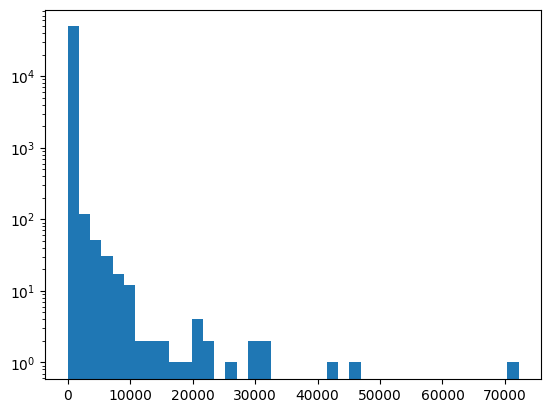

In [13]:
plt.hist(keys_count.values(), bins=40)
plt.yscale("log")
plt.show()

In [14]:
# !pip install wordcloud

In [15]:
def list_to_string(l: list[str]):
    s = ""
    for w in l:
        s = s + ' ' + w
    return s
df['Описание'] = df['Описание'].apply(list_to_string)
df['Описание']

ID на сайте  Источник
321970859    cian.ru      название офис московский область химки рабочи...
323570959    cian.ru      название торговый площадь московский область ...
319937619    cian.ru      название офис московский область мытищи ул ко...
319936797    cian.ru      название офис московский область мытищи ул ко...
319938233    cian.ru      название офис московский область мытищи ул ко...
                                               ...                        
4750280767   avito.ru     название офисный помещение кв м собственник о...
4750437026   avito.ru     название офисный помещение кв м собственник о...
4750004434   avito.ru     название офисный помещение кв м собственник о...
4749580770   avito.ru     название офисный помещение кв м собственник о...
4937488939   avito.ru     название торговый помещение трафик м² описани...
Name: Описание, Length: 29559, dtype: object

In [16]:
df['Описание']

ID на сайте  Источник
321970859    cian.ru      название офис московский область химки рабочи...
323570959    cian.ru      название торговый площадь московский область ...
319937619    cian.ru      название офис московский область мытищи ул ко...
319936797    cian.ru      название офис московский область мытищи ул ко...
319938233    cian.ru      название офис московский область мытищи ул ко...
                                               ...                        
4750280767   avito.ru     название офисный помещение кв м собственник о...
4750437026   avito.ru     название офисный помещение кв м собственник о...
4750004434   avito.ru     название офисный помещение кв м собственник о...
4749580770   avito.ru     название офисный помещение кв м собственник о...
4937488939   avito.ru     название торговый помещение трафик м² описани...
Name: Описание, Length: 29559, dtype: object

In [17]:
from sklearn.decomposition import LatentDirichletAllocation
from visualization import draw_wordcloud, draw_cluster_clouds
from sklearn.feature_extraction.text import CountVectorizer

cluster: 1; samples: 6180


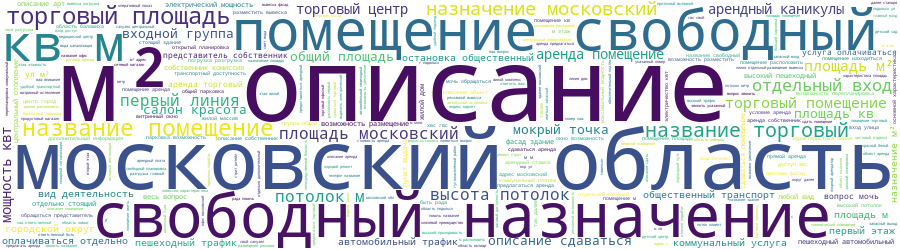

cluster: 2; samples: 8227


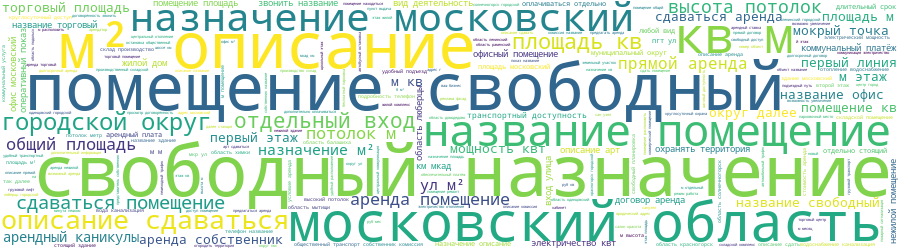

cluster: 3; samples: 1618


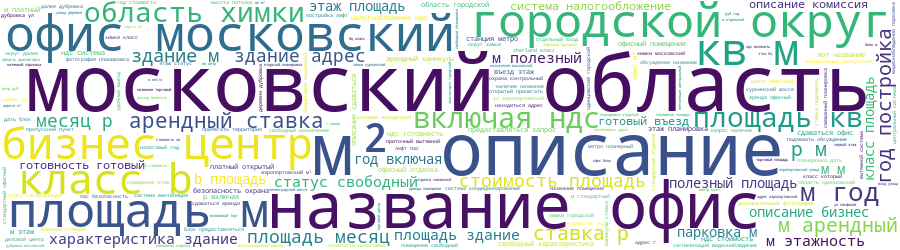

cluster: 4; samples: 3475


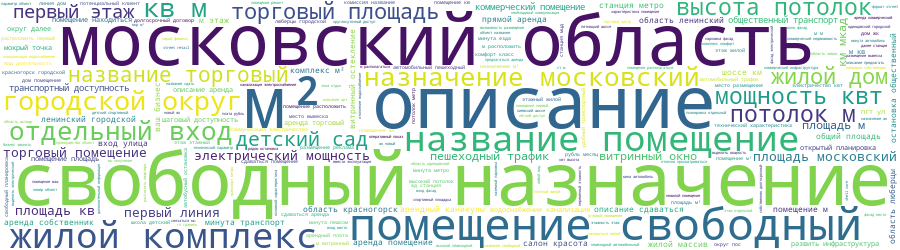

cluster: 5; samples: 1368


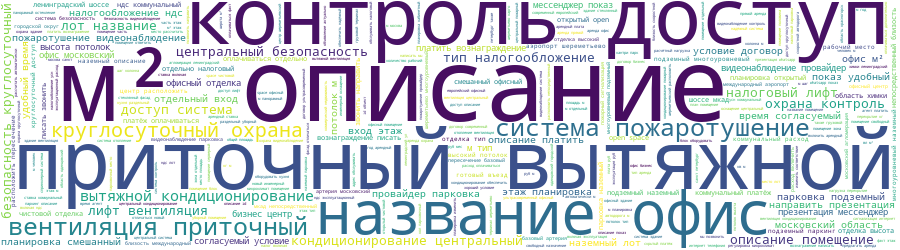

cluster: 6; samples: 2476


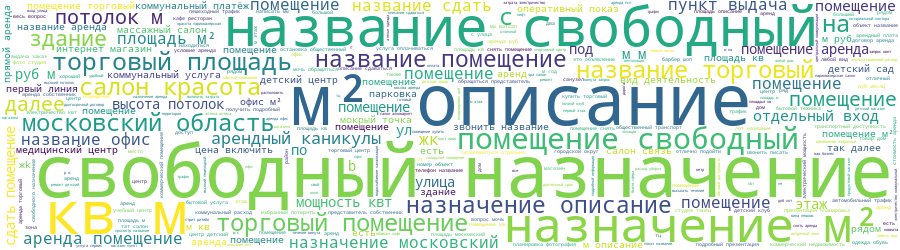

cluster: 7; samples: 888


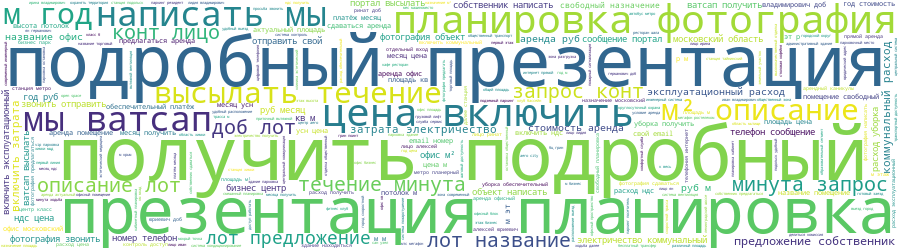

cluster: 8; samples: 2946


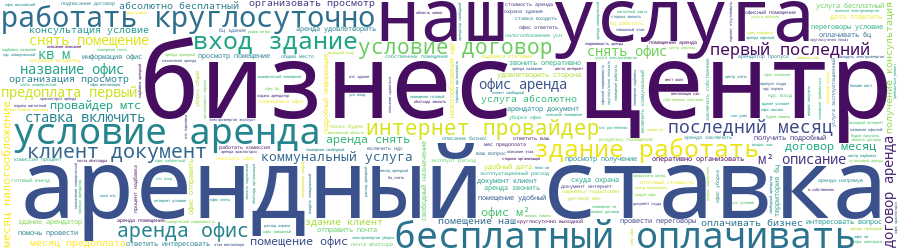

cluster: 9; samples: 1744


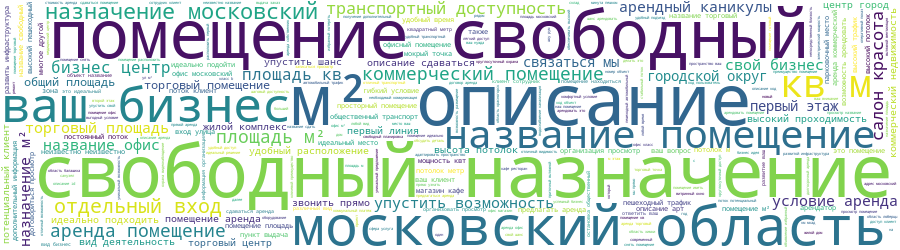

cluster: 10; samples: 637


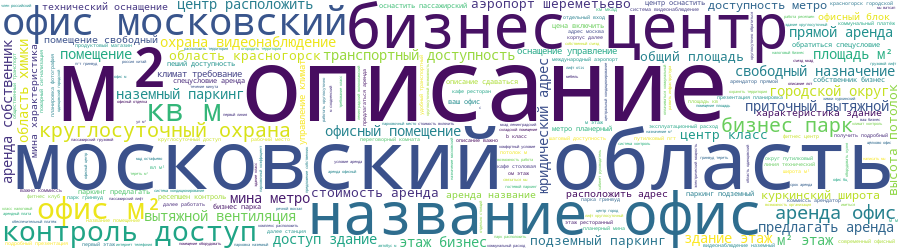

In [21]:
new_df = df.copy()
tf_vectorizer = CountVectorizer(min_df=10, max_df=50000, ).fit(new_df['Описание'])
bow = tf_vectorizer.transform(new_df['Описание'])

n_components = 10
lda = LatentDirichletAllocation(
    n_components=n_components, 
    random_state=42,
    learning_method='online'
)
lda.fit(bow)

labels_lda = np.argmax(lda.transform(bow), axis=1)
cloud_kwargs = { 'max_words': 3000, 'width': 900, 'height': 250 }
draw_cluster_clouds(new_df, labels_lda, n_components, alert_by='Описание', cloud_kwargs=cloud_kwargs)

In [22]:
column_names = ["Cluster " + str(i) for i in range(n_components)]
cluster_df_ = pd.DataFrame(lda.transform(bow), columns=column_names).set_index(new_df.index)

In [23]:
new_df = pd.concat([new_df, cluster_df_], axis=1).copy()

In [24]:
new_df

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,...,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2",название офис московский область химки рабочи...,55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,...,0.001053,0.001053,0.106424,0.001053,0.001053,0.001053,0.487249,0.001053,0.212217,0.187793
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,название торговый площадь московский область ...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,...,0.757324,0.001205,0.001205,0.201295,0.001205,0.032945,0.001205,0.001205,0.001205,0.001205
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А",название офис московский область мытищи ул ко...,55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,...,0.000953,0.068630,0.000953,0.000953,0.169779,0.000952,0.607339,0.000953,0.148537,0.000953
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А",название офис московский область мытищи ул ко...,55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,...,0.000953,0.068630,0.000953,0.000953,0.169779,0.000952,0.607339,0.000953,0.148537,0.000953
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А",название офис московский область мытищи ул ко...,55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,...,0.000953,0.068630,0.000953,0.000953,0.169779,0.000952,0.607339,0.000953,0.148537,0.000953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750280767,avito.ru,736325.0,2025-02-28 14:19:30,Агентство,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",название офисный помещение кв м собственник о...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,...,0.000893,0.039431,0.000893,0.000893,0.000893,0.183709,0.000893,0.770609,0.000893,0.000893
4750437026,avito.ru,270000.0,2025-02-28 14:19:23,Агентство,Котельники,Котельники,"Московская обл., Котельники, Дзержинское ш., 2",название офисный помещение кв м собственник о...,55.654477,37.856443,https://www.avito.ru/kotelniki/kommercheskaya_...,...,0.000901,0.000901,0.000901,0.000901,0.000901,0.208898,0.000901,0.783894,0.000901,0.000901
4750004434,avito.ru,743442.0,2025-02-28 14:19:06,Агентство,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",название офисный помещение кв м собственник о...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,...,0.000893,0.000893,0.025112,0.000893,0.000893,0.183143,0.000893,0.785494,0.000893,0.000893


In [25]:
new_df.to_csv("../../data/data_transformed2_misha.csv")